In [1]:
from models.gpkg import GeoPackage

In [ ]:
gpkg = GeoPackage()
df_0_10 = gpkg.read_layer('vindex_1985_2000_v8')
df_10_23 = gpkg.read_layer('vindex_2000_2023_v8')

In [4]:
df_0_10.describe()

,pol_id,regeneration_%_se,degeneration_%_se,forest_cover_2023_%_se,forest_formation_se,soybean_se,forest_plantation_se,urban_area_se,regeneration_%_ex,degeneration_%_ex,...,forest_plantation_ex,urban_area_ex,proximity_index,status_fundiario,txalfabeti_imputed,ex_score,se_score,ca_score,vulnerability_raw,vulnerability_index
count,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,...,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000
mean,70.000000,0.194282,0.128460,0.333148,31.713479,0.096619,0.055154,0.093513,11.673448,0.280099,...,0.128868,0.093280,0.794226,0.186170,0.581896,0.156745,0.095339,0.309129,-0.057045,0.410026
std,40.847277,0.263992,0.184263,0.219152,29.184106,0.206864,0.147690,0.240404,11.870827,0.172299,...,0.193730,0.179437,0.211921,0.372497,0.289568,0.130427,0.122284,0.172099,0.355793,0.212748
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.665940,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000051,0.000000,0.048118,-0.742759,0.000000
25%,35.000000,0.016260,0.009431,0.158778,3.715670,0.000000,0.000000,0.000000,3.541056,0.159524,...,0.008959,0.001901,0.715162,0.000000,0.320900,0.063426,0.009049,0.168881,-0.281394,0.275875
50%,70.000000,0.082759,0.066323,0.333283,23.673793,0.000000,0.000000,0.000000,5.881748,0.264243,...,0.038527,0.009068,0.874510,0.000000,0.655665,0.110851,0.031934,0.285931,-0.120784,0.371913
75%,105.000000,0.241979,0.170385,0.482689,54.214559,0.045706,0.035776,0.003436,16.928580,0.365781,...,0.180395,0.082124,0.940069,0.000000,0.853537,0.213765,0.138393,0.407222,0.143238,0.529787
max,140.000000,1.000000,1.000000,1.000000,98.652316,1.000000,1.000000,1.000000,51.061440,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.559449,0.511002,0.896901,0.929608,1.000000


In [65]:
from scipy.stats import ttest_ind

components = ['soybean_ex', 'agropec_ex', 'forest_plantation_ex']
results = {}

for comp in components:
    t_stat, p_value = ttest_ind(
        df_0_10[comp].dropna(),
        df_10_23[comp].dropna(),
        equal_var=False
    )
    results[comp] = {'t_statistic': t_stat, 'p_value': p_value}
    
print("Resultados do Teste t:")
for comp, res in results.items():
    print(f"{comp}: t = {res['t_statistic']:.3f}, p = {res['p_value']:.4f}")


Resultados do Teste t:
soybean_ex: t = -2.684, p = 0.0077
agropec_ex: t = -0.136, p = 0.8916
forest_plantation_ex: t = -1.610, p = 0.1086


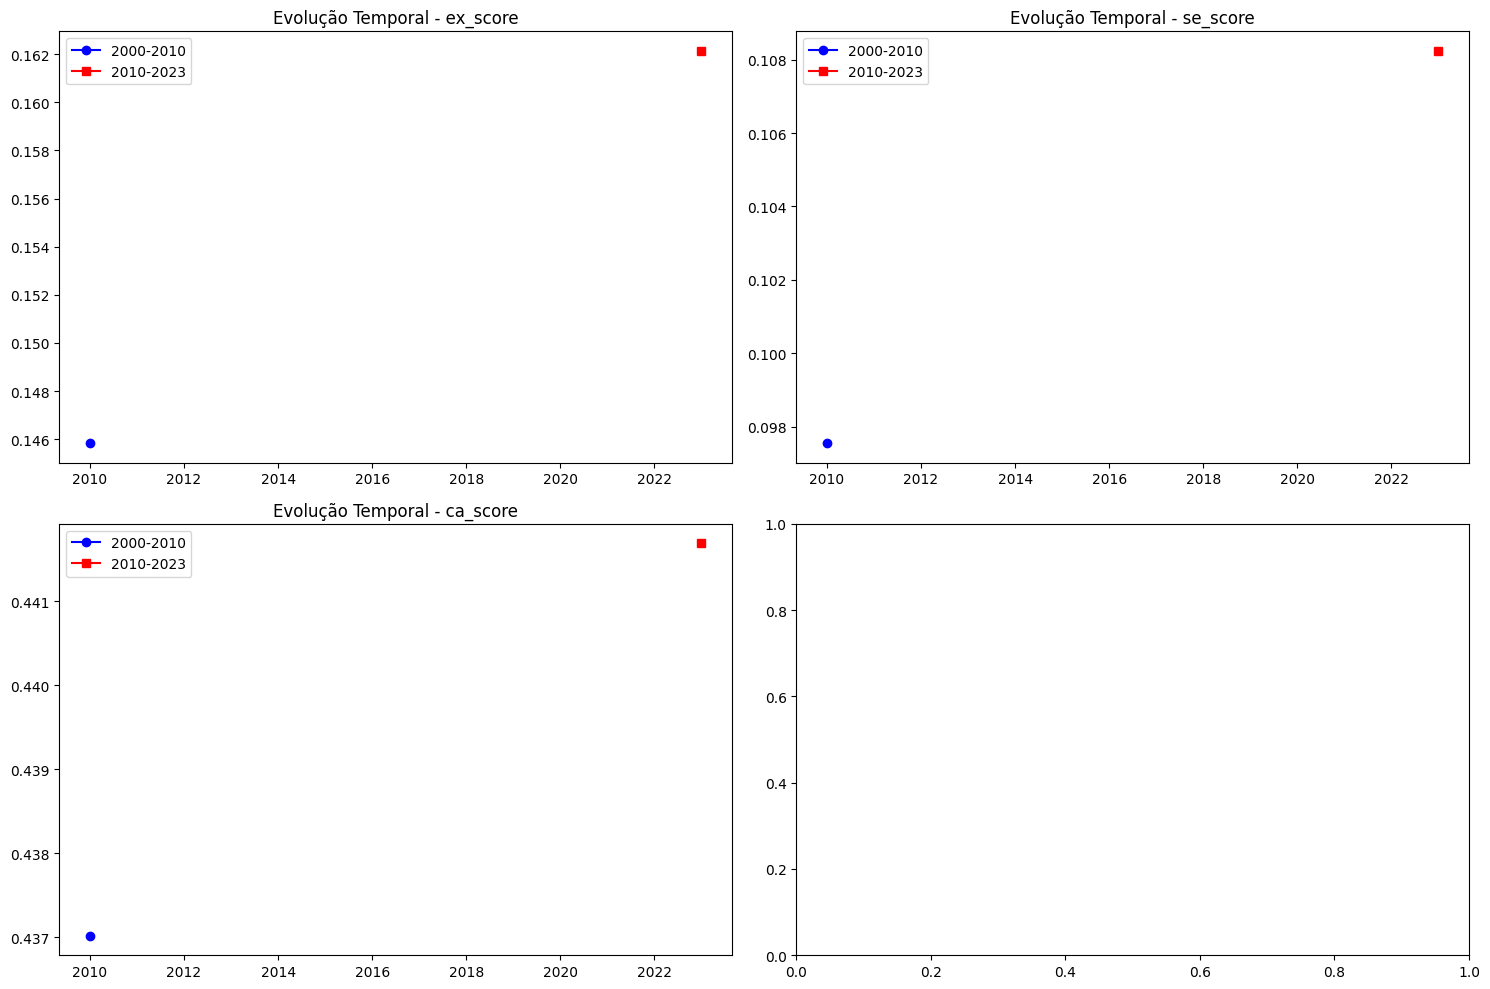

In [52]:
import matplotlib.pyplot as plt

# Criar gráficos de série temporal comparativa
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
components = ['ex_score', 'se_score', 'ca_score']
df_0_10['ano'] = 2010
df_10_23['ano'] = 2023

for i, comp in enumerate(components):
    ax = axes[i//2, i%2]
    
    # Médias anuais por período
    if 'ano' in df_0_10.columns:
        mean_2000 = df_0_10.groupby('ano')[comp].mean()
        mean_2010 = df_10_23.groupby('ano')[comp].mean()
        
        ax.plot(mean_2000.index, mean_2000.values, 'b-', label='2000-2010', marker='o')
        ax.plot(mean_2010.index, mean_2010.values, 'r-', label='2010-2023', marker='s')
        ax.set_title(f'Evolução Temporal - {comp}')
        ax.legend()
    
plt.tight_layout()
plt.show()

In [66]:
# Calcular mudanças percentuais médias
mean_2000 = df_0_10[components].mean()
mean_2010 = df_10_23[components].mean()

percent_change = ((mean_2010 - mean_2000) / mean_2000) * 100

print("Mudança Percentual Média:")
for comp in components:
    print(f"{comp}: {percent_change[comp]:.2f}%")

Mudança Percentual Média:
soybean_ex: 61.34%
agropec_ex: 1.43%
forest_plantation_ex: 34.02%


In [61]:
# Gerar relatório comparativo
print("RELATÓRIO COMPARATIVO - IVA 2000-2010 vs 2010-2023")
print("=" * 50)

for comp in components:
    print(f"\n{comp}:")
    print(f"  Média 1985-2000: {df_0_10[comp].mean():.3f}")
    print(f"  Média 2000-2023: {df_10_23[comp].mean():.3f}")
    print(f"  Diferença: {df_10_23[comp].mean() - df_0_10[comp].mean():.3f}")
    print(f"  Significância (p-value): {results[comp]['p_value']:.4f}")

RELATÓRIO COMPARATIVO - IVA 2000-2010 vs 2010-2023

soybean_ex:
  Média 1985-2000: 0.166
  Média 2000-2023: 0.225
  Diferença: 0.059
  Significância (p-value): 0.0750

ex_score:
  Média 1985-2000: 0.160
  Média 2000-2023: 0.156
  Diferença: -0.004
  Significância (p-value): 0.5884

se_score:
  Média 1985-2000: 0.106
  Média 2000-2023: 0.101
  Diferença: -0.006
  Significância (p-value): 0.5749

ca_score:
  Média 1985-2000: 0.453
  Média 2000-2023: 0.437
  Diferença: -0.016
  Significância (p-value): 0.2602

vulnerability_index:
  Média 1985-2000: 0.526
  Média 2000-2023: 0.498
  Diferença: -0.029
  Significância (p-value): 0.2172


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import rcParams

# Configuração do estilo
plt.style.use('default')
rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette("husl")

def plot_ethnicity_vulnerability_stats(gdf, vulnerability_columns=None):
    """
    Analisa e visualiza estatísticas de vulnerabilidade por etnia_nome_nome_nome
    
    Parameters:
    -----------
    gdf : GeoDataFrame
        GeoDataFrame com colunas de vulnerabilidade e etnia
    vulnerability_columns : list, optional
        Lista de colunas de vulnerabilidade para analisar
        Se None, usa colunas padrão
    """
    
    if vulnerability_columns is None:
        vulnerability_columns = [
            'vulnerability_index', 
            'ex_score', 
            'se_score', 
            'ca_score'
        ]
    
    # Verificar se as colunas existem
    available_cols = [col for col in vulnerability_columns if col in gdf.columns]
    if not available_cols:
        raise ValueError("Nenhuma coluna de vulnerabilidade encontrada no GeoDataFrame")
    
    # Criar figura com subplots
    n_cols = len(available_cols)
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    # 1. Gráfico de barras com médias por etnia
    for i, col in enumerate(available_cols):
        if i >= len(axes):
            break
            
        # Calcular estatísticas por etnia
        stats_by_ethnicity = gdf.groupby('etnia_nome')[col].agg([
            'mean', 'std', 'count', 'min', 'max', 'median'
        ]).round(3)
        
        # Ordenar por média (maior para menor)
        stats_by_ethnicity = stats_by_ethnicity.sort_values('mean', ascending=False)
        
        # Plotar gráfico de barras
        bars = axes[i].bar(stats_by_ethnicity.index, stats_by_ethnicity['mean'],
                         yerr=stats_by_ethnicity['std'], 
                         capsize=5, alpha=0.8,
                         color=plt.cm.Set3(np.arange(len(stats_by_ethnicity))))
        
        axes[i].set_title(f'{col.upper()} - Média por Etnia\n(Ordenado por maior vulnerabilidade)')
        axes[i].set_ylabel('Valor Médio')
        axes[i].tick_params(axis='x', rotation=45)
        
        # Adicionar valores nas barras
        for j, (idx, row) in enumerate(stats_by_ethnicity.iterrows()):
            axes[i].text(j, row['mean'] + row['std'] + 0.01, 
                       f'{row["mean"]:.3f}\n(n={row["count"]})', 
                       ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # 2. Boxplots detalhados por etnia
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    for i, col in enumerate(available_cols):
        if i >= len(axes):
            break
            
        # Boxplot por etnia_nome
        boxplot_data = []
        ethnicities = []
        
        # Ordenar etnias pela mediana
        ethnicity_medians = gdf.groupby('etnia_nome')[col].median().sort_values(ascending=False)
        
        for ethnicity in ethnicity_medians.index:
            data = gdf[gdf['etnia_nome'] == ethnicity][col].dropna()
            if len(data) > 0:
                boxplot_data.append(data)
                ethnicities.append(ethnicity)
        
        box = axes[i].boxplot(boxplot_data, labels=ethnicities, patch_artist=True)
        
        # Colorir boxes
        colors = plt.cm.Set3(np.arange(len(ethnicities)))
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
        
        axes[i].set_title(f'{col.upper()} - Distribuição por Etnia\n(Ordenado por mediana)')
        axes[i].set_ylabel('Valor')
        axes[i].tick_params(axis='x', rotation=45)
        
        # Adicionar informação de sample size
        for j, ethnicity in enumerate(ethnicities):
            n = len(gdf[gdf['etnia_nome'] == ethnicity])
            axes[i].text(j + 1, axes[i].get_ylim()[0] - 0.05, 
                       f'n={n}', ha='center', va='top', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Heatmap de correlações entre componentes por etnia
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Heatmap 1: Médias por etnia
    ethnicity_means = gdf.groupby('etnia_nome')[available_cols].mean()
    sns.heatmap(ethnicity_means, annot=True, fmt='.3f', cmap='RdYlGn_r', 
                center=ethnicity_means.values.mean(), ax=axes[0])
    axes[0].set_title('Médias de Vulnerabilidade por Etnia')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)
    
    # Heatmap 2: Contagem por etnia
    ethnicity_counts = gdf.groupby('etnia_nome')[available_cols].count()
    sns.heatmap(ethnicity_counts, annot=True, fmt='.0f', cmap='Blues', ax=axes[1])
    axes[1].set_title('Número de Observações por Etnia')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Ranking detalhado
    print("=" * 80)
    print("RANKING DETALHADO POR ETNIA")
    print("=" * 80)
    
    for col in available_cols:
        print(f"\n{col.upper()} - Ranking por Etnia:")
        print("-" * 40)
        
        stats = gdf.groupby('etnia_nome')[col].agg(['mean', 'std', 'count', 'median']).round(4)
        stats = stats.sort_values('mean', ascending=False)
        
        for i, (ethnicity, row) in enumerate(stats.iterrows(), 1):
            rank = f"{i}º"
            print(f"{rank:4} {ethnicity:20}: {row['mean']:.4f} ± {row['std']:.4f} "
                  f"(mediana: {row['median']:.4f}, n={row['count']})")
    
    return stats

# Função adicional para análise comparativa
def plot_ethnicity_comparison(gdf, primary_ethnicity, compare_with=None):
    """
    Compara uma etnia específica com outras
    
    Parameters:
    -----------
    gdf : GeoDataFrame
        GeoDataFrame com os dados
    primary_ethnicity : str
        Etnia principal para comparação
    compare_with : list, optional
        Lista de etnias para comparar, se None compara com todas
    """
    
    if compare_with is None:
        compare_with = [eth for eth in gdf['etnia_nome'].unique() if eth != primary_ethnicity]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    vulnerability_cols = ['vulnerability_index', 'ex_score', 'se_score', 'ca_score']
    
    for i, col in enumerate(vulnerability_cols):
        if col not in gdf.columns or i >= len(axes):
            continue
        
        # Dados para comparação
        primary_data = gdf[gdf['etnia_nome'] == primary_ethnicity][col].dropna()
        comparison_data = []
        labels = [primary_ethnicity]
        
        for ethnicity in compare_with:
            data = gdf[gdf['etnia_nome'] == ethnicity][col].dropna()
            if len(data) > 0:
                comparison_data.append(data)
                labels.append(ethnicity)
        
        # Juntar todos os dados
        all_data = [primary_data] + comparison_data
        
        # Plot violin plot
        violin = axes[i].violinplot(all_data, showmeans=True, showmedians=True)
        
        # Colorir violinos
        colors = ['red'] + ['lightblue'] * len(comparison_data)
        for j, pc in enumerate(violin['bodies']):
            pc.set_facecolor(colors[j])
            pc.set_alpha(0.7)
        
        axes[i].set_title(f'{col.upper()} - {primary_ethnicity} vs Outras Etnias')
        axes[i].set_ylabel('Valor')
        axes[i].set_xticks(range(1, len(labels) + 1))
        axes[i].set_xticklabels(labels, rotation=45)
        
        # Adicionar informação estatística
        for j, data in enumerate(all_data, 1):
            axes[i].text(j, np.min(data) - 0.05, f'n={len(data)}', 
                       ha='center', va='top', fontsize=8)
    
    plt.tight_layout()
    plt.show()

In [73]:
df_10_23.etnia_nome.replace({'0': 'Sem dados'})

0      Sem dados
1        Guarani
2       Kaingang
3      Sem dados
4      Sem dados
         ...    
136    Sem dados
137    Sem dados
138    Sem dados
139    Sem dados
140    Sem dados
Name: etnia_nome, Length: 141, dtype: object

In [80]:
df_10_23.etnia_nome.replace({'Guaraní': 'Guarani', "Guaraní,Kaingang": 'Guarani - Kaingang', '0': 'Sem dados'}, inplace=True)

In [81]:
df_10_23.etnia_nome.unique()

array(['Sem dados', 'Guarani', 'Kaingang', 'Charrua',
       'Guarani - Kaingang', 'Xokleng', 'Guarani Mbya'], dtype=object)

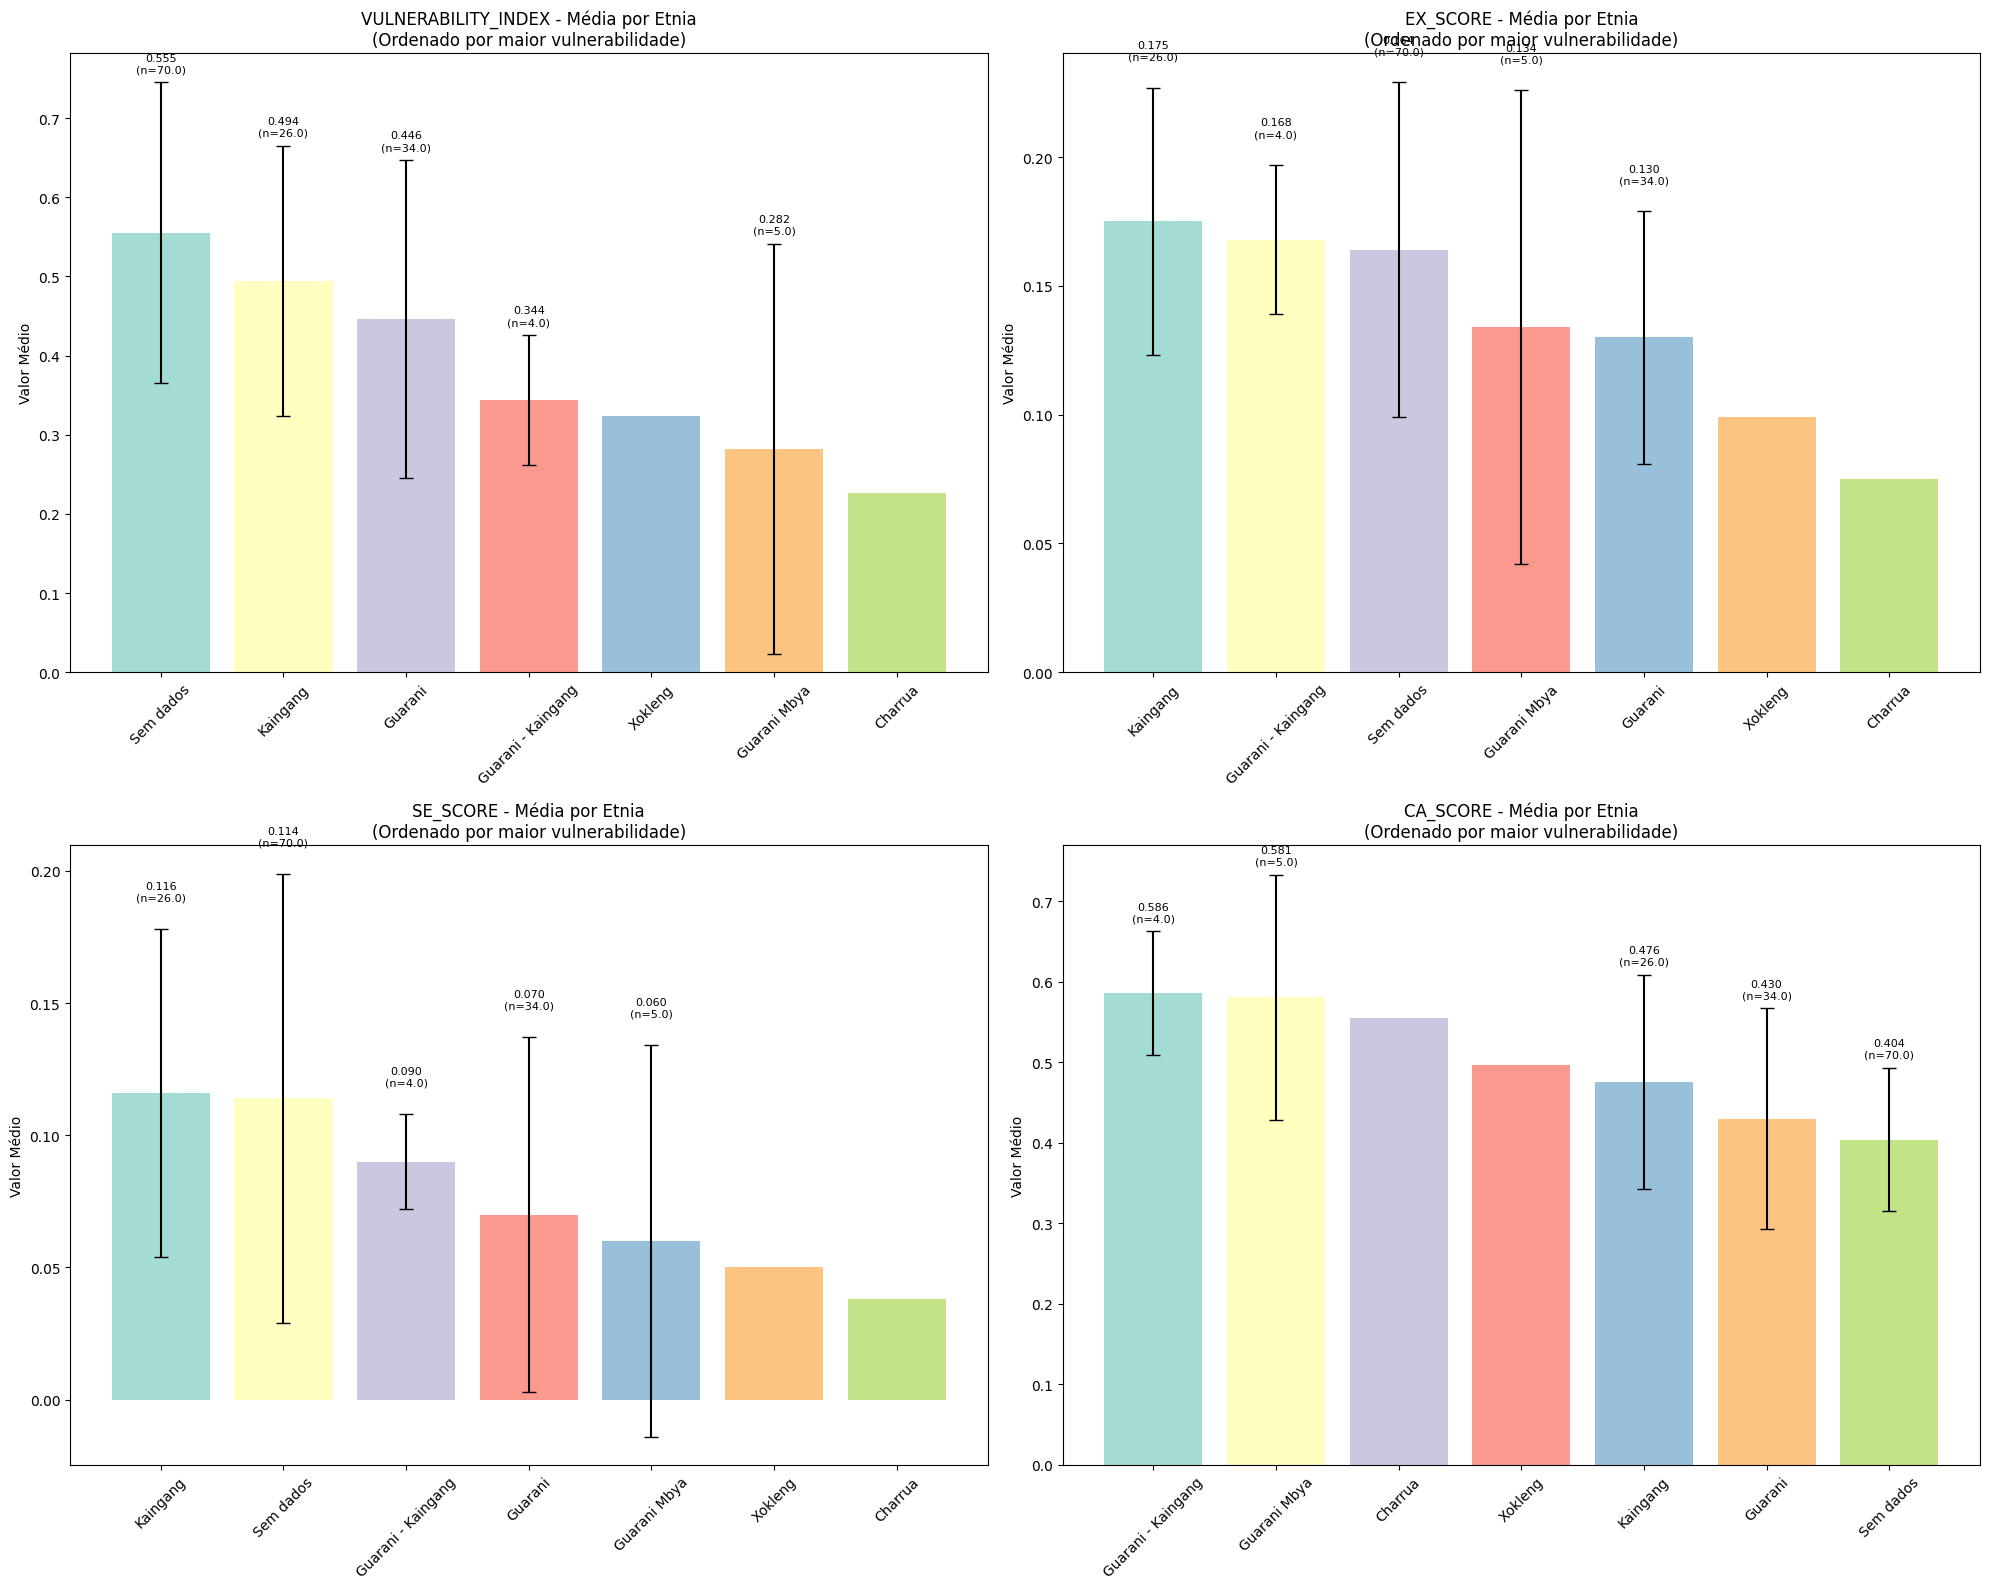

C:\Users\adminitsd\AppData\Local\Temp\ipykernel_17684\2188106393.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(boxplot_data, labels=ethnicities, patch_artist=True)
C:\Users\adminitsd\AppData\Local\Temp\ipykernel_17684\2188106393.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(boxplot_data, labels=ethnicities, patch_artist=True)
C:\Users\adminitsd\AppData\Local\Temp\ipykernel_17684\2188106393.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(boxplot_data, labels=ethnicities, patch_artist=True)
C:\Users\adminitsd\AppData\Local\Temp\ipykerne

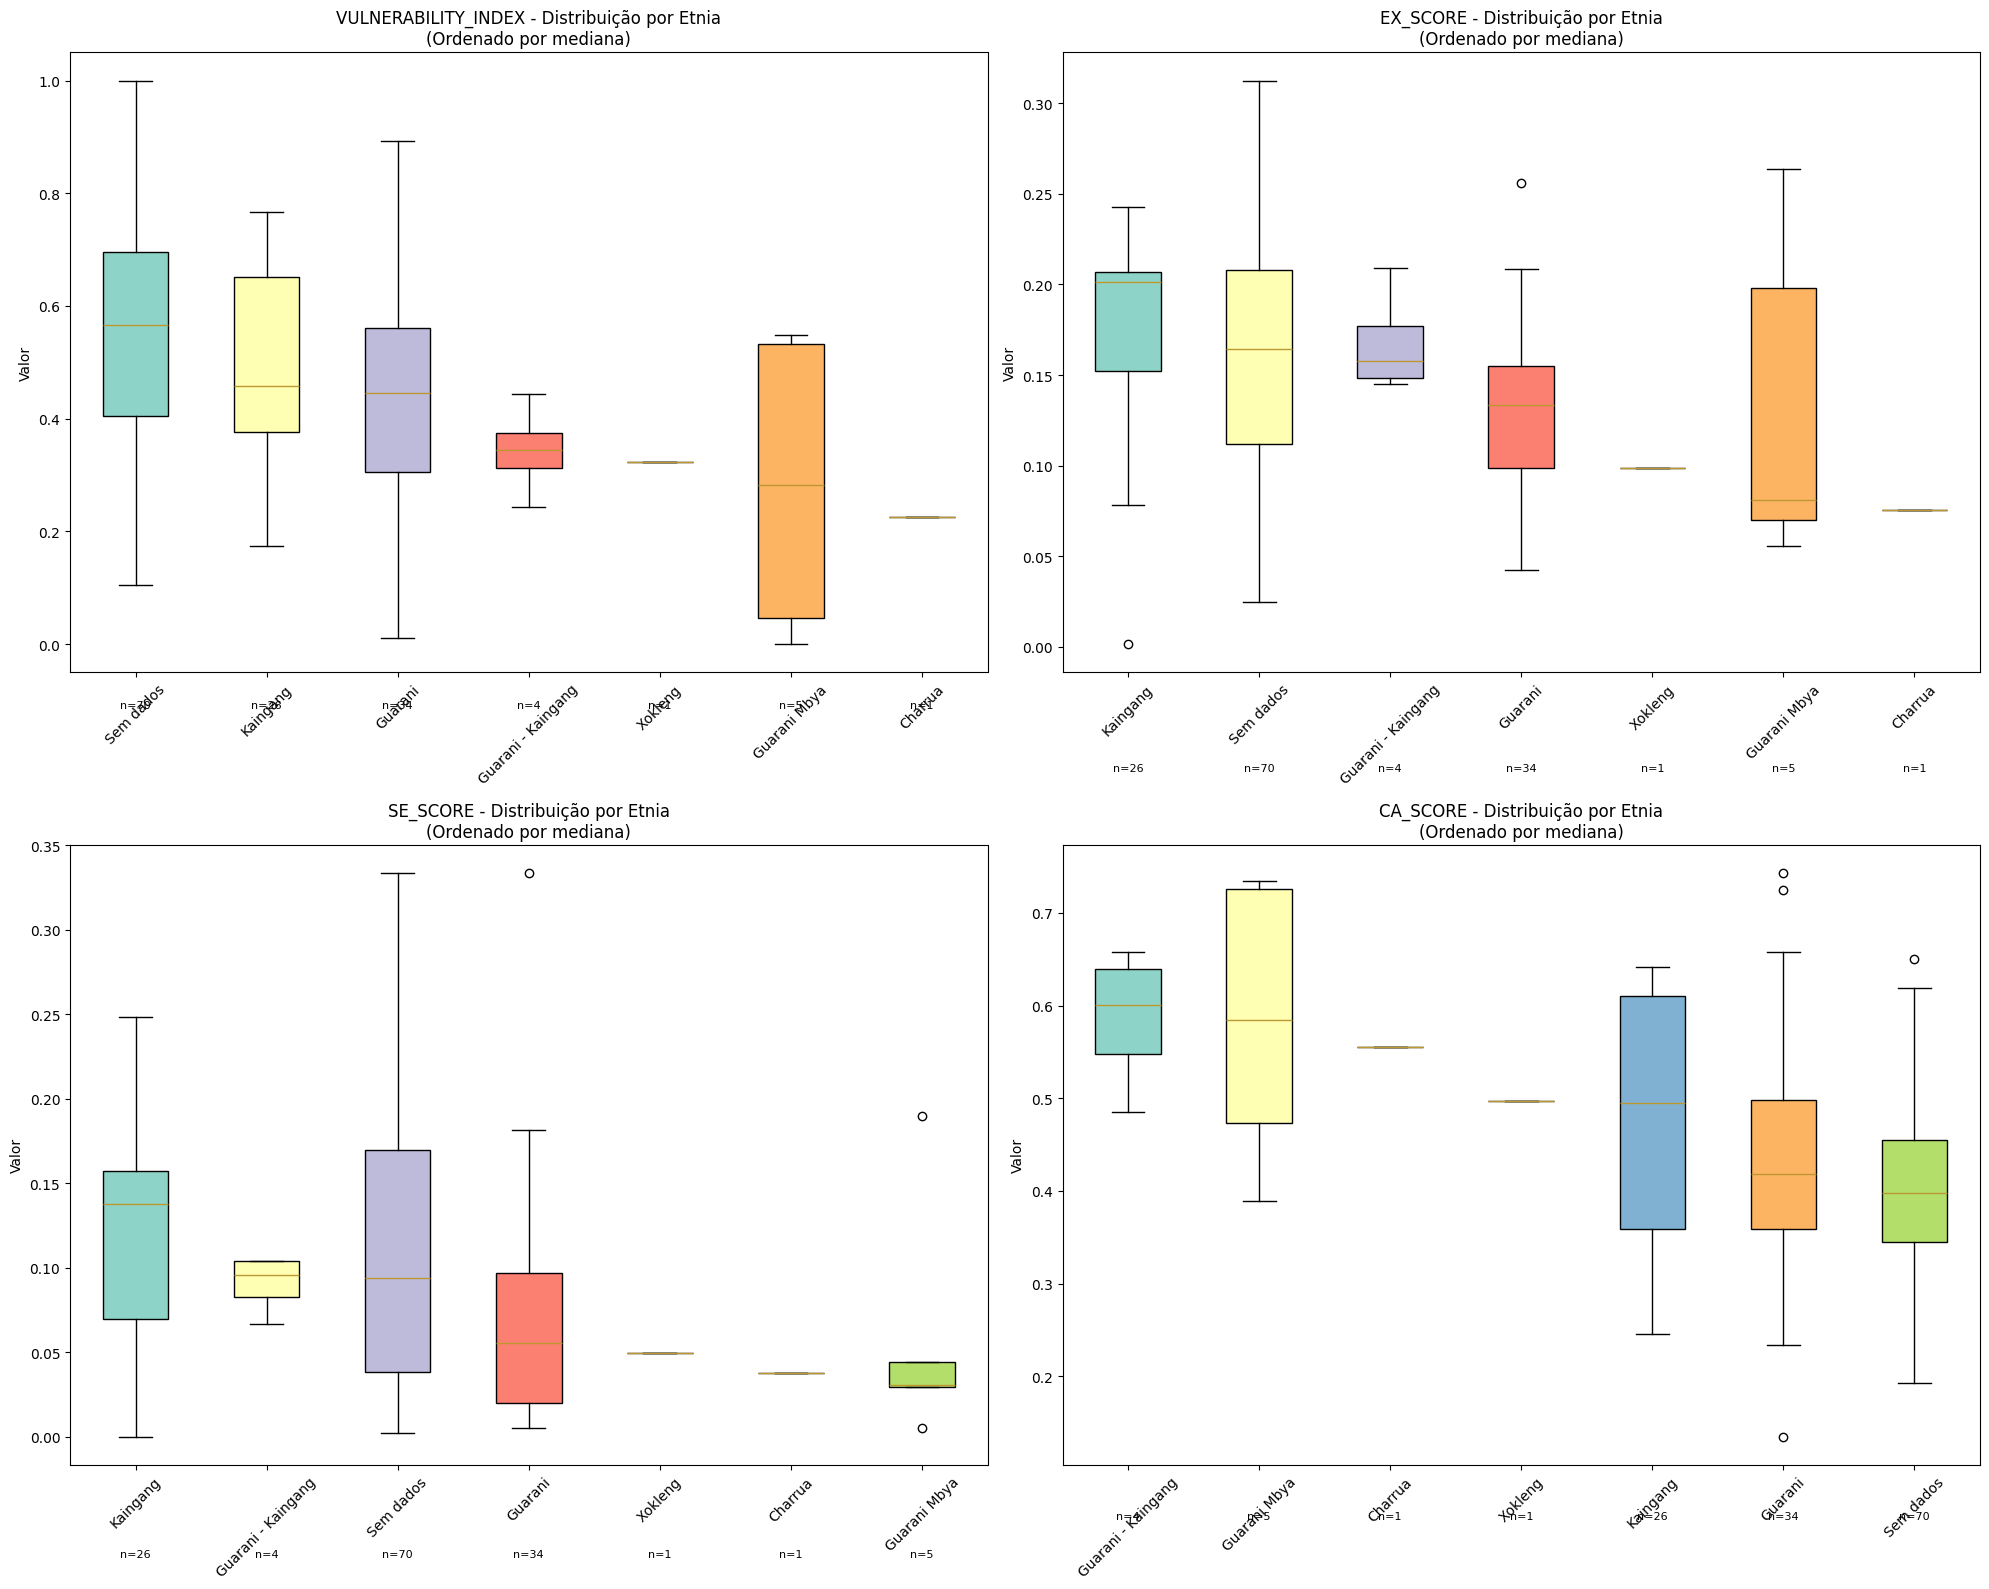

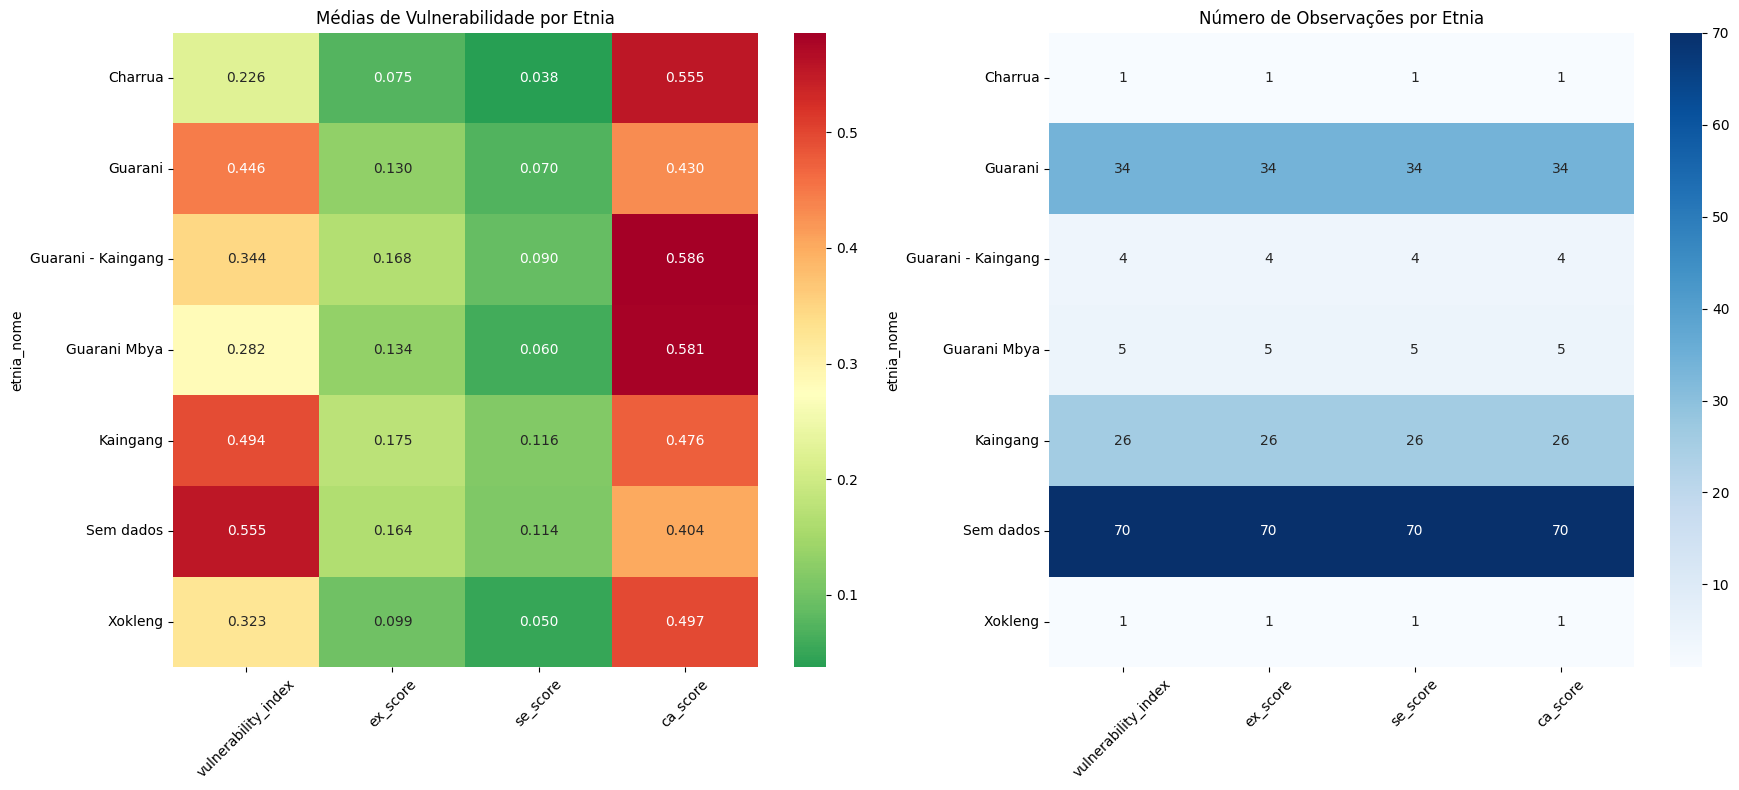

RANKING DETALHADO POR ETNIA

VULNERABILITY_INDEX - Ranking por Etnia:
----------------------------------------
1º   Sem dados           : 0.5546 ± 0.1896 (mediana: 0.5659, n=70.0)
2º   Kaingang            : 0.4935 ± 0.1711 (mediana: 0.4584, n=26.0)
3º   Guarani             : 0.4459 ± 0.2012 (mediana: 0.4451, n=34.0)
4º   Guarani - Kaingang  : 0.3440 ± 0.0821 (mediana: 0.3440, n=4.0)
5º   Xokleng             : 0.3229 ± nan (mediana: 0.3229, n=1.0)
6º   Guarani Mbya        : 0.2819 ± 0.2589 (mediana: 0.2831, n=5.0)
7º   Charrua             : 0.2259 ± nan (mediana: 0.2259, n=1.0)

EX_SCORE - Ranking por Etnia:
----------------------------------------
1º   Kaingang            : 0.1753 ± 0.0521 (mediana: 0.2011, n=26.0)
2º   Guarani - Kaingang  : 0.1675 ± 0.0294 (mediana: 0.1579, n=4.0)
3º   Sem dados           : 0.1644 ± 0.0654 (mediana: 0.1644, n=70.0)
4º   Guarani Mbya        : 0.1337 ± 0.0921 (mediana: 0.0812, n=5.0)
5º   Guarani             : 0.1297 ± 0.0492 (mediana: 0.1337, n=34.0)
6

In [82]:
stats = plot_ethnicity_vulnerability_stats(df_10_23)

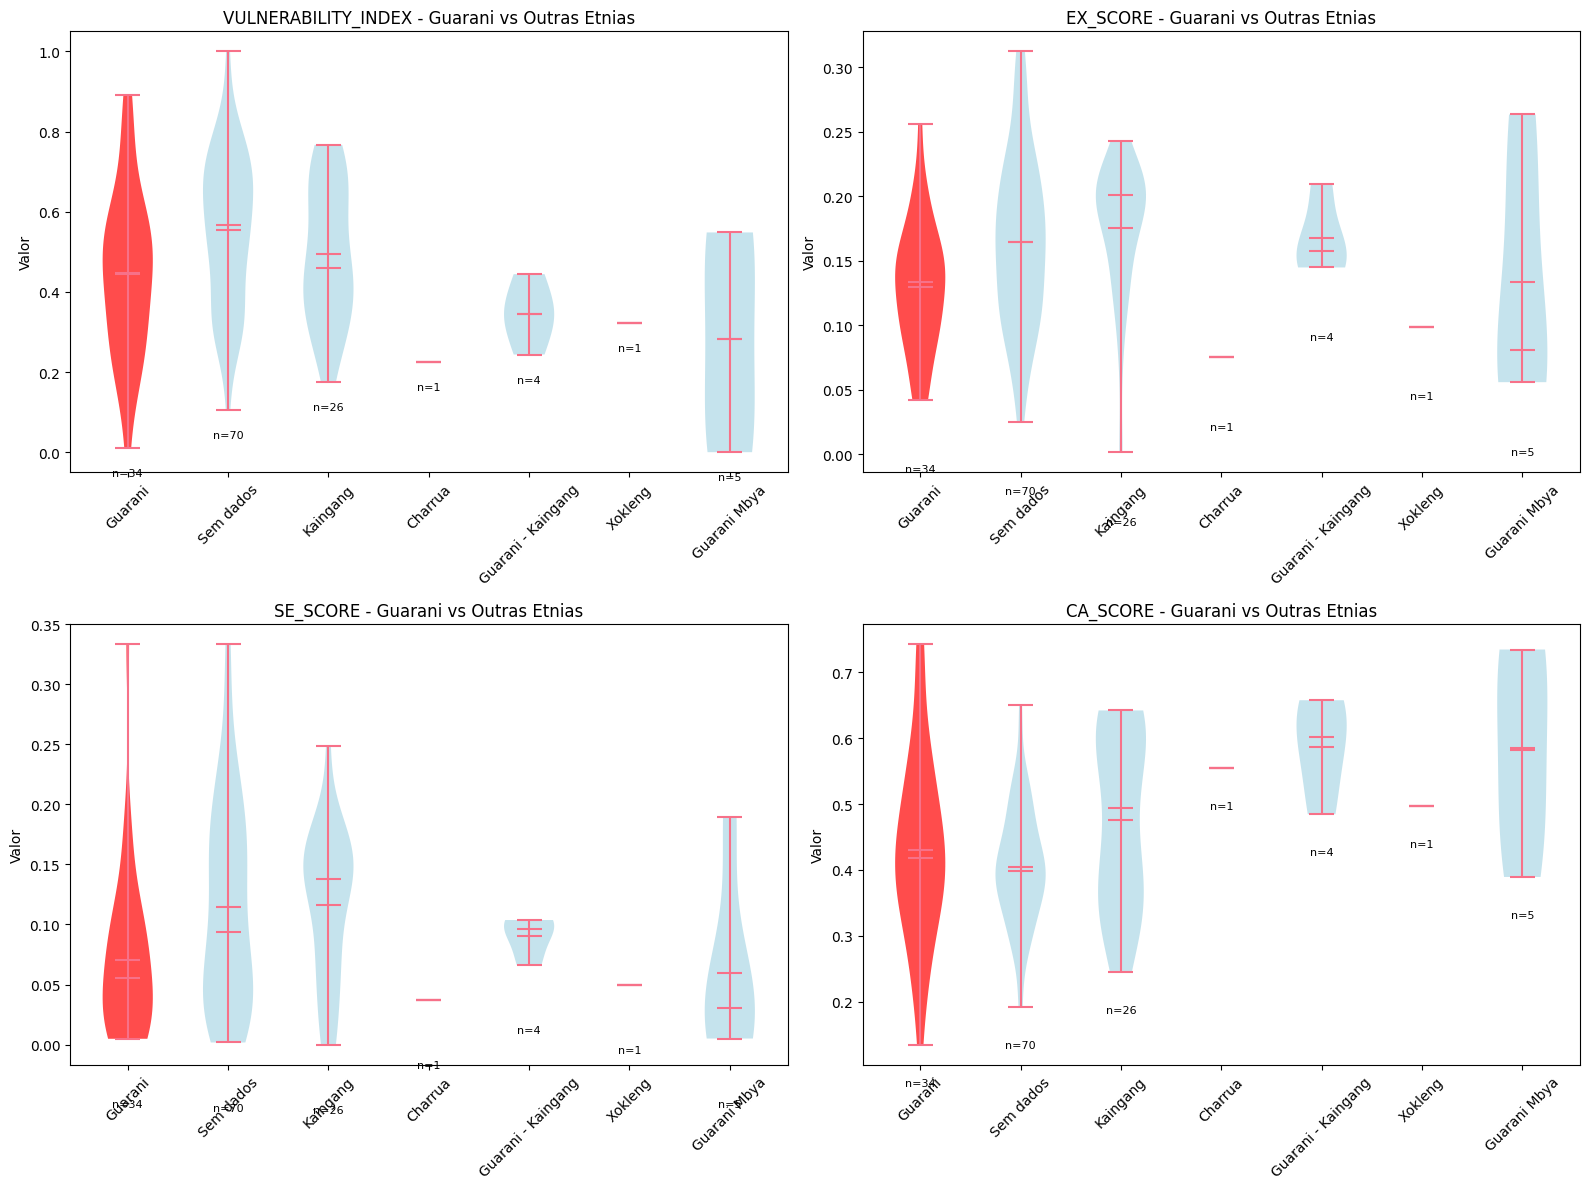

In [83]:
plot_ethnicity_comparison(df_10_23, 'Guarani')